# CropCatcher — Playground

**FR** — Bac à sable du pipeline CropCatcher : points-clés, appariement, ratio de Lowe, RANSAC, homographie, localisation, comparaison des méthodes, recherche IIIF. Images synthétiques, exécution hors-ligne.

**EN** — Playground for the CropCatcher pipeline: keypoints, matching, Lowe's ratio, RANSAC, homography, localization, method comparison, IIIF search. Synthetic images, runs offline.

## 0. Setup

**FR** — Imports et fonction d'affichage pour les images OpenCV (BGR).

**EN** — Imports and a display helper for OpenCV (BGR) images.

In [1]:
from __future__ import annotations

import tempfile
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from cropcatcher import Index, Matcher
from cropcatcher.features import get_extractor
from cropcatcher.matching.descriptors import match_descriptors
from cropcatcher.visualization import draw_keypoints, draw_localization, draw_matches

%matplotlib inline


def show(image: np.ndarray, title: str = "", ax=None):
    """Display a grayscale or BGR OpenCV image with matplotlib."""
    owns_fig = ax is None
    if owns_fig:
        _, ax = plt.subplots(figsize=(5, 5))
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
    if owns_fig:
        plt.show()

## 1. Corpus de démonstration / Demo corpus

**FR** — CropCatcher lit des chemins de fichiers. On génère donc de faux folios texturés avec une zone « enluminure », écrits dans un dossier temporaire. La requête est un extrait exact de cette zone.

**EN** — CropCatcher reads file paths, so we generate textured fake folios with an "illumination" region and write them to a temp directory. The query is an exact extract of that region.

In [2]:
def make_folio(seed: int, size: int = 900, illumination_box: tuple[int, int, int, int] | None = None):
    """Generate a synthetic, textured manuscript-like page with a colorful illumination region."""
    rng = np.random.default_rng(seed)
    page = np.full((size, size, 3), (222, 232, 240), dtype=np.uint8)  # parchment-ish BGR

    cv2.rectangle(page, (40, 40), (size - 40, size - 40), (90, 70, 40), 4)

    # text block, kept clear of the lower half so the illumination box never overlaps it
    for y in range(110, size // 2, 18):
        x_end = int(rng.integers(size // 2, size - 100))
        cv2.line(page, (90, y), (x_end, y), (60, 45, 30), 1, cv2.LINE_AA)

    for _ in range(70):
        pt1 = tuple(int(v) for v in rng.integers(0, size, size=2))
        pt2 = tuple(int(v) for v in rng.integers(0, size, size=2))
        color = tuple(int(c) for c in rng.integers(40, 200, size=3))
        shape = rng.integers(0, 3)
        if shape == 0:
            cv2.rectangle(page, pt1, pt2, color, int(rng.integers(1, 3)))
        elif shape == 1:
            cv2.circle(page, pt1, int(rng.integers(4, 18)), color, int(rng.integers(1, 3)))
        else:
            cv2.line(page, pt1, pt2, color, 1, cv2.LINE_AA)

    if illumination_box is None:
        box_size = 220
        margin = 40
        # stays fully inside the border and below the text block -> never clipped
        x0 = int(rng.integers(margin + 10, size - margin - box_size - 10))
        y0 = int(rng.integers(size // 2 + 20, size - margin - box_size - 10))
        illumination_box = (x0, y0, x0 + box_size, y0 + box_size)
    x0, y0, x1, y1 = illumination_box
    cv2.rectangle(page, (x0, y0), (x1, y1), (20, 20, 20), 2)
    for _ in range(45):
        pt1 = (int(rng.integers(x0, x1)), int(rng.integers(y0, y1)))
        pt2 = (int(rng.integers(x0, x1)), int(rng.integers(y0, y1)))
        color = tuple(int(c) for c in rng.integers(20, 230, size=3))
        shape = rng.integers(0, 3)
        if shape == 0:
            cv2.circle(page, pt1, int(rng.integers(4, 16)), color, -1)
        elif shape == 1:
            cv2.rectangle(page, pt1, pt2, color, -1)
        else:
            cv2.line(page, pt1, pt2, color, 2, cv2.LINE_AA)

    return page, illumination_box

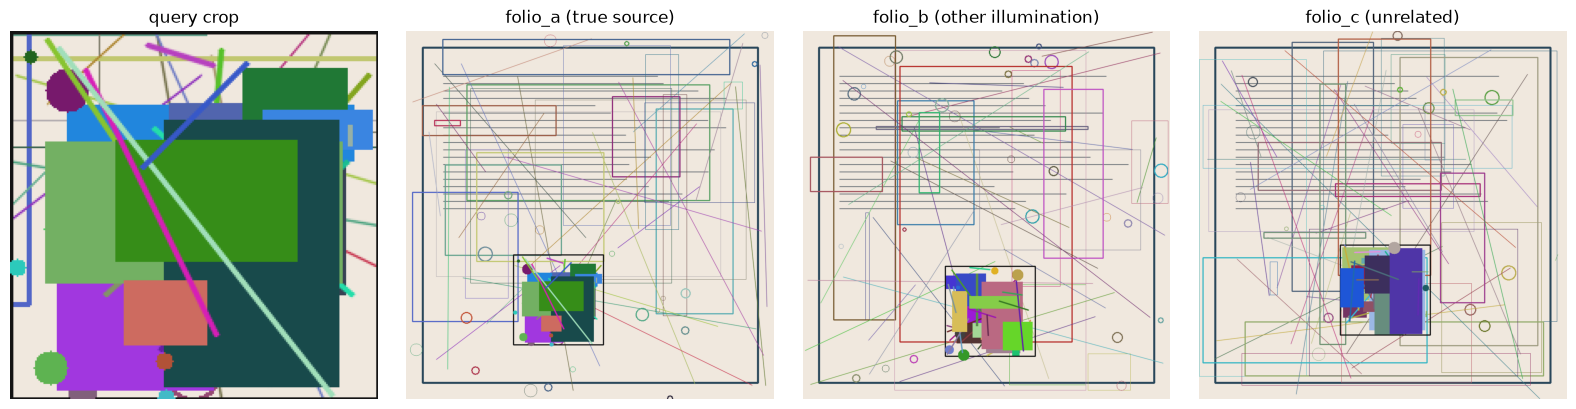

In [3]:
demo_dir = Path(tempfile.mkdtemp(prefix="cropcatcher_playground_"))
query_dir = demo_dir / "query"
candidates_dir = demo_dir / "candidates"
query_dir.mkdir()
candidates_dir.mkdir()

folio_a, box_a = make_folio(seed=1)
folio_b, box_b = make_folio(seed=2)
folio_c, _ = make_folio(seed=3)  # unrelated / negative candidate
crop_a = folio_a[box_a[1] : box_a[3], box_a[0] : box_a[2]].copy()

query_path = query_dir / "query_crop.png"
folio_a_path = candidates_dir / "folio_a.png"
folio_b_path = candidates_dir / "folio_b.png"
folio_c_path = candidates_dir / "folio_c_negative.png"

cv2.imwrite(str(query_path), crop_a)
cv2.imwrite(str(folio_a_path), folio_a)
cv2.imwrite(str(folio_b_path), folio_b)
cv2.imwrite(str(folio_c_path), folio_c)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
show(crop_a, "query crop", axes[0])
show(folio_a, "folio_a (true source)", axes[1])
show(folio_b, "folio_b (other illumination)", axes[2])
show(folio_c, "folio_c (unrelated)", axes[3])
plt.tight_layout()
plt.show()

## 2. Détection de points-clés / Keypoint detection

**FR** — Chaque méthode détecte des points-clés et calcule un descripteur local. SIFT, AKAZE et STAR produisent aussi une échelle, d'où les cercles de tailles variables. ORB est plus rapide, moins robuste aux fortes transformations.

**EN** — Each method detects keypoints and computes a local descriptor. SIFT, AKAZE and STAR also produce a scale, hence the variable-sized circles. ORB is faster, less robust to strong transformations.

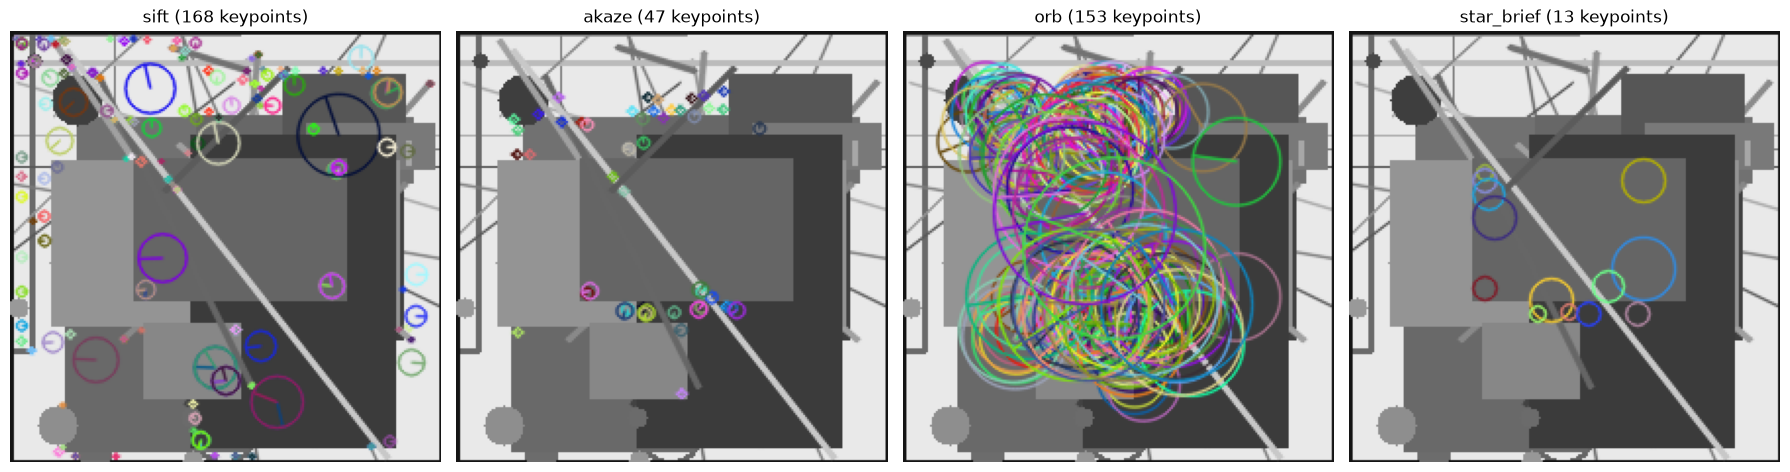

In [4]:
query_gray = cv2.imread(str(query_path), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, method in zip(axes, ["sift", "akaze", "orb", "star_brief"]):
    extractor = get_extractor(method)
    keypoints, descriptors = extractor.detect_and_compute(query_gray)
    show(draw_keypoints(query_gray, keypoints), f"{method} ({len(keypoints)} keypoints)", ax)
plt.tight_layout()
plt.show()

## 3. Appariement + ratio de Lowe / Matching + Lowe's ratio

**FR** — On cherche les deux plus proches voisins de chaque descripteur. Le test de Lowe ne garde l'appariement que si le meilleur est nettement plus proche que le second : `distance(best) < ratio * distance(second)`. Un `ratio` plus petit est plus strict.

**EN** — We look for each descriptor's two nearest neighbours. Lowe's test keeps a match only if the best is clearly closer than the second: `distance(best) < ratio * distance(second)`. A smaller `ratio` is stricter.

In [5]:
sift = get_extractor("sift")
query_kp, query_desc = sift.detect_and_compute(query_gray)
folio_a_gray = cv2.imread(str(folio_a_path), cv2.IMREAD_GRAYSCALE)
candidate_kp, candidate_desc = sift.detect_and_compute(folio_a_gray)

print(f"{'ratio':>6} | {'kept matches':>12}")
for ratio in [1.0, 0.9, 0.8, 0.75, 0.6, 0.4]:
    kept = match_descriptors(query_desc, candidate_desc, sift.norm_type, ratio=ratio)
    print(f"{ratio:>6.2f} | {len(kept):>12}")

 ratio | kept matches
  1.00 |          168
  0.90 |          127
  0.80 |          118
  0.75 |          115
  0.60 |          107
  0.40 |           97


## 4. RANSAC & homographie / RANSAC & homography

**FR** — Le nombre brut d'appariements n'est pas une preuve : beaucoup sont des coïncidences. RANSAC cherche l'homographie cohérente avec le plus grand sous-ensemble, puis étiquette chaque appariement *inlier* ou *outlier*. `Matcher.explain()` permet de visualiser l'appariement.

**EN** — The raw match count is not evidence: many matches are coincidental. RANSAC finds the homography that the largest subset agrees on, then labels each match *inlier* or *outlier*. `Matcher.explain()` returns all of it for one pair.

MatchResult(source='/tmp/cropcatcher_playground_unmweul1/candidates/folio_a.png', score=0.990, matches=115, inliers=113, inlier_ratio=0.983, bbox=(261, 546, 482, 767))

homography:
[[ 9.99815501e-01 -6.43311802e-04  2.62003310e+02]
 [-1.14673835e-03  9.99040224e-01  5.47045500e+02]
 [-1.21351933e-06 -1.42376921e-06  1.00000000e+00]]


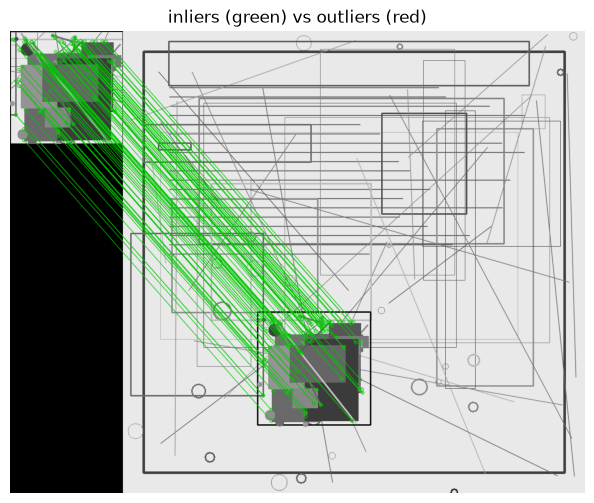

In [6]:
matcher = Matcher(method="sift")
debug = matcher.explain(query=query_path, candidate=folio_a_path)

print(debug.result)
print()
print("homography:")
print(debug.result.homography)

fig, ax = plt.subplots(figsize=(12, 6))
show(draw_matches(debug), "inliers (green) vs outliers (red)", ax)
plt.show()

## 5. Localisation du crop / Crop localization

**FR** — Projeter les quatre coins de la requête via l'homographie donne le contour détecté, soit `debug.result.bbox`. On le compare à la boîte de découpe réelle (`box_a`) : elles doivent presque coïncider.

**EN** — Projecting the query's four corners through the homography gives the detected outline, i.e. `debug.result.bbox`. We compare it to the actual crop box (`box_a`): they should nearly coincide.

predicted bbox: (261, 546, 482, 767)
ground-truth box_a: (262, 547, 482, 767)


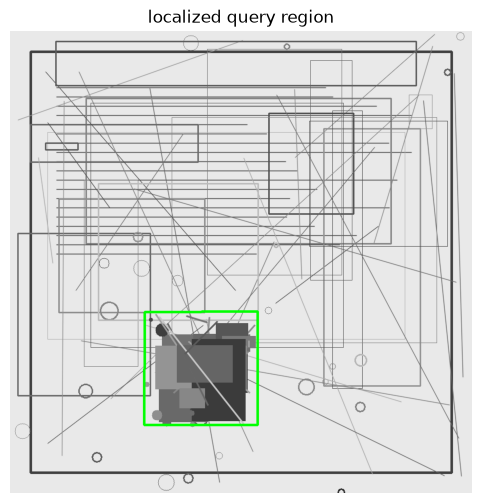

In [7]:
print("predicted bbox:", debug.result.bbox)
print("ground-truth box_a:", box_a)

fig, ax = plt.subplots(figsize=(6, 6))
show(draw_localization(debug.candidate_image, debug.query_image.shape, debug.result.homography), "localized query region", ax)
plt.show()

## 6. SIFT vs AKAZE vs ORB vs STAR+BRIEF

**FR** — Même recherche avec les quatre méthodes utilisables telles quelles, sur les mêmes candidats (`folio_a` vraie source, `folio_c` négatif) : score, inliers, ratio et temps.

**EN** — The same search with all four out-of-the-box methods, over the same candidates (`folio_a` true source, `folio_c` negative): score, inliers, ratio and time.

**FR** — `"surf"` est enregistré mais breveté et absent des wheels PyPI. `Matcher(method="surf")` lève une `RuntimeError` explicite, sauf build OpenCV avec `-DOPENCV_ENABLE_NONFREE=ON`. Il est donc exclu de la comparaison.

**EN** — `"surf"` is registered but patented and absent from the PyPI wheels. `Matcher(method="surf")` raises an explicit `RuntimeError` unless OpenCV is built with `-DOPENCV_ENABLE_NONFREE=ON`. It is therefore excluded here.

In [8]:
rows = []
for method in ["sift", "akaze", "orb", "star_brief"]:
    m = Matcher(method=method)
    start = time.perf_counter()
    results = m.search(query=query_path, images=[folio_a_path, folio_c_path])
    elapsed_ms = (time.perf_counter() - start) * 1000
    best = results.best
    rows.append((method, Path(best.source).name, best.score, best.matches, best.inliers, best.inlier_ratio, elapsed_ms))

header = f"{'method':<6} | {'best source':<20} | {'score':>6} | {'matches':>7} | {'inliers':>7} | {'inlier_ratio':>12} | {'time_ms':>8}"
print(header)
print("-" * len(header))
for method, source, score, matches, inliers, inlier_ratio, elapsed_ms in rows:
    print(f"{method:<6} | {source:<20} | {score:>6.3f} | {matches:>7} | {inliers:>7} | {inlier_ratio:>12.3f} | {elapsed_ms:>8.1f}")

method | best source          |  score | matches | inliers | inlier_ratio |  time_ms
------------------------------------------------------------------------------------
sift   | folio_a.png          |  0.984 |     116 |     113 |        0.974 |    167.2
akaze  | folio_a.png          |  0.984 |      38 |      37 |        0.974 |    127.0
orb    | folio_a.png          |  0.707 |       8 |       8 |        1.000 |     25.4
star_brief | folio_a.png          |  0.720 |       9 |       9 |        1.000 |     28.4


## 7. Score et classement / Scoring and ranking

**FR** — `Matcher.search` classe les candidats d'un dossier par score décroissant. Le score repose surtout sur les inliers RANSAC : `folio_c`, tout aussi texturé, doit rester nettement en dessous.

**EN** — `Matcher.search` ranks a directory's candidates by descending score. The score rests mainly on RANSAC inliers, so `folio_c`, just as textured, should stay clearly below.

In [9]:
results = matcher.search(query=query_path, images=candidates_dir)

header = f"{'rank':>4} | {'source':<24} | {'score':>6} | {'inliers':>7} | {'inlier_ratio':>12} | {'bbox'}"
print(header)
print("-" * len(header))
for rank, result in enumerate(results, start=1):
    print(f"{rank:>4} | {Path(result.source).name:<24} | {result.score:>6.3f} | {result.inliers:>7} | {result.inlier_ratio:>12.3f} | {result.bbox}")

rank | source                   |  score | inliers | inlier_ratio | bbox
------------------------------------------------------------------------
   1 | folio_a.png              |  0.984 |     113 |        0.974 | (261, 546, 482, 767)
   2 | folio_b.png              |  0.339 |       5 |        0.455 | None
   3 | folio_c_negative.png     |  0.000 |       0 |        0.000 | None


## 8. Indexation persistante / Persistent indexing

**FR** — Sur un corpus stable, `Index` précalcule et sauvegarde les descripteurs une fois, au lieu de les recalculer à chaque requête.

**EN** — On a stable corpus, `Index` precomputes and saves descriptors once instead of recomputing them per query.

In [10]:
index = Index(method="sift")
index.add_images(candidates_dir)
print(f"indexed {len(index)} candidates")

index_path = demo_dir / "collection.cropcatcher"
index.save(index_path)
loaded_index = Index.load(index_path)

index_results = loaded_index.search(query_path)
print("best match after save/load round-trip:", Path(index_results.best.source).name, index_results.best.score)

indexed 3 candidates
best match after save/load round-trip: folio_a.png 0.9894736842105263


## 9. Recherche IIIF (optionnel) / IIIF search (optional)

**FR** — `search_iiif` résout un manifeste (Presentation v2/v3) et télécharge chaque image via l'Image API, en résolution réduite. Renseignez `manifest_url` et `query_path`, puis passez `RUN_IIIF_DEMO = True`. Désactivé par défaut pour rester hors-ligne.

**EN** — `search_iiif` resolves a manifest (Presentation v2/v3) and downloads each image through the Image API at reduced size. Fill in `manifest_url` and `query_path`, then set `RUN_IIIF_DEMO = True`. Off by default so the notebook stays offline.

In [2]:
%%time

RUN_IIIF_DEMO = True
manifest_url = "https://damsssl.llgc.org.uk/iiif/2.0/5152608/manifest.json"  # replace with a real IIIF manifest URL

if RUN_IIIF_DEMO:
    iiif_matcher = Matcher(method="sift")
    iiif_results = iiif_matcher.search_iiif(query="/home/lterriel/Documents/ENC-PSL/SideProjects/IIIF_image_matcher/notebooks/test_crops/test1.png", manifests=manifest_url)
    for result in iiif_results:
        print(result)
else:
    print("Skipped — set RUN_IIIF_DEMO = True and a real manifest_url to try this cell.")

MatchResult(source='https://iiif.llyfrgell.cymru/iiif/5152635', score=0.976, matches=500, inliers=480, inlier_ratio=0.960, bbox=(25, 335, 442, 572))
MatchResult(source='https://iiif.llyfrgell.cymru/iiif/5152678', score=0.859, matches=51, inliers=39, inlier_ratio=0.765, bbox=(518, 36, 520, 48))
MatchResult(source='https://iiif.llyfrgell.cymru/iiif/5152711', score=0.396, matches=35, inliers=13, inlier_ratio=0.371, bbox=(349, 975, 349, 975))
MatchResult(source='https://iiif.llyfrgell.cymru/iiif/5152663', score=0.389, matches=17, inliers=8, inlier_ratio=0.471, bbox=(669, 510, 671, 512))
MatchResult(source='https://iiif.llyfrgell.cymru/iiif/5152631', score=0.378, matches=33, inliers=12, inlier_ratio=0.364, bbox=(10, 771, 30, 966))
MatchResult(source='https://iiif.llyfrgell.cymru/iiif/5152624', score=0.373, matches=15, inliers=7, inlier_ratio=0.467, bbox=None)
MatchResult(source='https://iiif.llyfrgell.cymru/iiif/5152626', score=0.373, matches=25, inliers=10, inlier_ratio=0.400, bbox=(704, 7

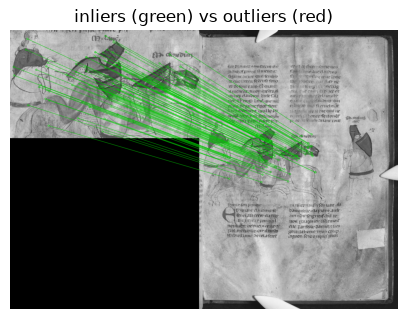

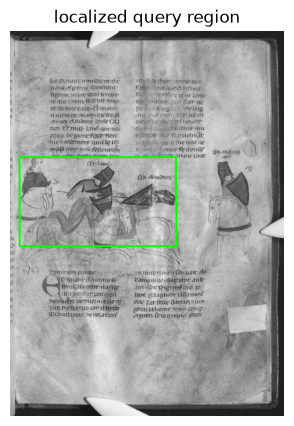

In [3]:
best = iiif_results.best

debug = iiif_matcher.explain_iiif(
    query="/home/lterriel/Documents/ENC-PSL/SideProjects/IIIF_image_matcher/notebooks/test_crops/test1.png",
    service_id=best.source,  # IIIF service id of the best-ranked candidate
)

show(draw_matches(debug), "inliers (green) vs outliers (red)")
show(draw_localization(debug.candidate_image, debug.query_image.shape, debug.result.homography), "localized query region")

## Pour aller plus loin / Next steps

**FR** —
- Remplacez les images synthétiques par vos crops et folios.
- Ajustez `ratio`, `ransac_reproj_threshold` et `min_inliers`.
- Comparez SIFT/AKAZE/ORB sur vos données.

**EN** —
- Swap the synthetic images for your own crops and folios.
- Tune `ratio`, `ransac_reproj_threshold` and `min_inliers`.
- Compare SIFT/AKAZE/ORB on your own data.